In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [19]:
# =============================================================================
# STEP 1 — DATA
# =============================================================================

def fetch_intraday(ticker, interval="15m", total_days=59):
    end   = datetime.datetime.today()
    start = end - datetime.timedelta(days=total_days)

    df = yf.download(
        ticker,
        start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"),
        interval=interval,
        auto_adjust=True,
        progress=False
    )
    return df[["Close"]].rename(columns={"Close": ticker})

meta = fetch_intraday("SPY")
qqq  = fetch_intraday("QQQ")

data         = pd.concat([meta, qqq], axis=1).dropna()
data.columns = ["SPY", "QQQ"]

In [20]:
# =============================================================================
# CELL 2 — DATA
# =============================================================================

def fetch_intraday(ticker, interval="15m", total_days=59):
    end   = datetime.datetime.today()
    start = end - datetime.timedelta(days=total_days)
    df    = yf.download(
        ticker,
        start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"),
        interval=interval,
        auto_adjust=True,
        progress=False
    )
    return df[["Close"]].rename(columns={"Close": ticker})

meta         = fetch_intraday("META")
qqq          = fetch_intraday("QQQ")
data         = pd.concat([meta, qqq], axis=1).dropna()
data.columns = ["META", "QQQ"]

meta_vals = data["META"].values.astype(float)
qqq_vals  = data["QQQ"].values.astype(float)

print(f"Data shape: {data.shape}")
print(f"Window: {data.index[0].date()} → {data.index[-1].date()}")

Data shape: (1092, 2)
Window: 2026-02-25 → 2026-04-24


In [21]:
# =============================================================================
# STEP 3 — SPREAD & Z-SCORE
# =============================================================================

spread = pd.Series(e, index=data.index)

# Robust z-score using MAD (resistant to fat tails and outlier events)
def rolling_mad_zscore(spread, window):
    """
    Z-score using median and MAD instead of mean and std.
    MAD scaled by 1.4826 to match std for Gaussian data.
    """
    median = spread.rolling(window).median()
    mad    = (spread - median).abs().rolling(window).median() * 1.4826
    return (spread - median) / mad

window         = 78    # 3 days of 15-min bars (26 bars/day × 3)
zscore         = rolling_mad_zscore(spread, window)
zscore_clipped = zscore.clip(-4, 4)

# Remove market open bars (13:30 UTC = 09:30 ET)
data["time"] = data.index.time
market_open  = datetime.time(13, 30)
open_mask    = data["time"] == market_open

# Remove tariff shock regime (Apr 7-10 2026)
tariff_shock = (data.index >= "2026-04-07") & (data.index <= "2026-04-10")

# Final clean z-score
zscore_clean = zscore_clipped.copy()
zscore_clean[open_mask.values] = np.nan
zscore_clean[tariff_shock]     = np.nan

# Diagnostics
print("=== Z-Score Stats (MAD, window=78) ===")
print(zscore_clean.describe())
print(f"\nBars beyond ±1σ: {(zscore_clean.abs() > 1).sum()} / {zscore_clean.notna().sum()}")
print(f"Bars beyond ±2σ: {(zscore_clean.abs() > 2).sum()} / {zscore_clean.notna().sum()}")
print(f"Bars removed — open spikes: {open_mask.sum()}")
print(f"Bars removed — tariff shock: {tariff_shock.sum()}")

=== Z-Score Stats (MAD, window=78) ===
count    829.000000
mean       0.019582
std        1.139791
min       -4.000000
25%       -0.610515
50%        0.015630
75%        0.650442
max        4.000000
dtype: float64

Bars beyond ±1σ: 260 / 829
Bars beyond ±2σ: 71 / 829
Bars removed — open spikes: 34
Bars removed — tariff shock: 78


In [22]:
# =============================================================================
# STEP 4 — SIGNAL GENERATION
# =============================================================================

entry_threshold = 2.0
exit_threshold  = 0.0

signals = pd.Series(0, index=zscore_clean.index)
position = 0  # current position: 1 = long spread, -1 = short spread, 0 = flat

for t in range(1, len(zscore_clean)):
    z = zscore_clean.iloc[t]

    if np.isnan(z):
        signals.iloc[t] = 0
        position = 0
        continue

    if position == 0:
        if z < -entry_threshold:
            position = 1       # spread too low — go long
        elif z > entry_threshold:
            position = -1      # spread too high — go short

    elif position == 1:
        if z >= exit_threshold:
            position = 0       # spread reverted — exit long

    elif position == -1:
        if z <= exit_threshold:
            position = 0       # spread reverted — exit short

    signals.iloc[t] = position

# Diagnostics
print("=== Signal Stats ===")
print(signals.value_counts())

trades = signals.diff().fillna(0) != 0
print(f"\nTotal trade events (entries + exits): {trades.sum()}")
print(f"Bars in long  position: {(signals ==  1).sum()}")
print(f"Bars in short position: {(signals == -1).sum()}")
print(f"Bars flat:              {(signals ==  0).sum()}")

=== Signal Stats ===
 0    982
-1     58
 1     52
Name: count, dtype: int64

Total trade events (entries + exits): 108
Bars in long  position: 52
Bars in short position: 58
Bars flat:              982


In [23]:
# =============================================================================
# STEP 5 — BACKTEST ENGINE
# =============================================================================

# Align beta (hedge ratio) with data index
beta_series = pd.Series(beta[:, 1], index=data.index)

# Dollar returns per bar
meta_ret = data["META"].pct_change()
qqq_ret  = data["QQQ"].pct_change()

# Corrected sign — when z < -2, META is cheap, we sell spread
spread_ret = -(meta_ret - beta_series * qqq_ret)

# Strategy return — shift(1) to avoid lookahead bias
strategy_ret = signals.shift(1) * spread_ret
strategy_ret = strategy_ret.dropna()

# Equity curve (compounded)
equity_curve = (1 + strategy_ret).cumprod()


# =============================================================================
# PERFORMANCE METRICS
# =============================================================================

ann_factor   = 26 * 252

total_return = equity_curve.iloc[-1] - 1
sharpe       = (strategy_ret.mean() / strategy_ret.std()) * np.sqrt(ann_factor)
rolling_max  = equity_curve.cummax()
drawdown     = (equity_curve - rolling_max) / rolling_max
max_drawdown = drawdown.min()
winning_bars = (strategy_ret > 0).sum() / (strategy_ret != 0).sum()

print("=== Performance Metrics ===")
print(f"Total Return:    {total_return:.2%}")
print(f"Sharpe Ratio:    {sharpe:.2f}")
print(f"Max Drawdown:    {max_drawdown:.2%}")
print(f"Win Rate:        {winning_bars:.2%}")
print(f"Bars in market:  {(signals != 0).sum()}")
print(f"Total bars:      {len(strategy_ret)}")

=== Performance Metrics ===
Total Return:    4.04%
Sharpe Ratio:    3.00
Max Drawdown:    -2.13%
Win Rate:        53.64%
Bars in market:  110
Total bars:      1091


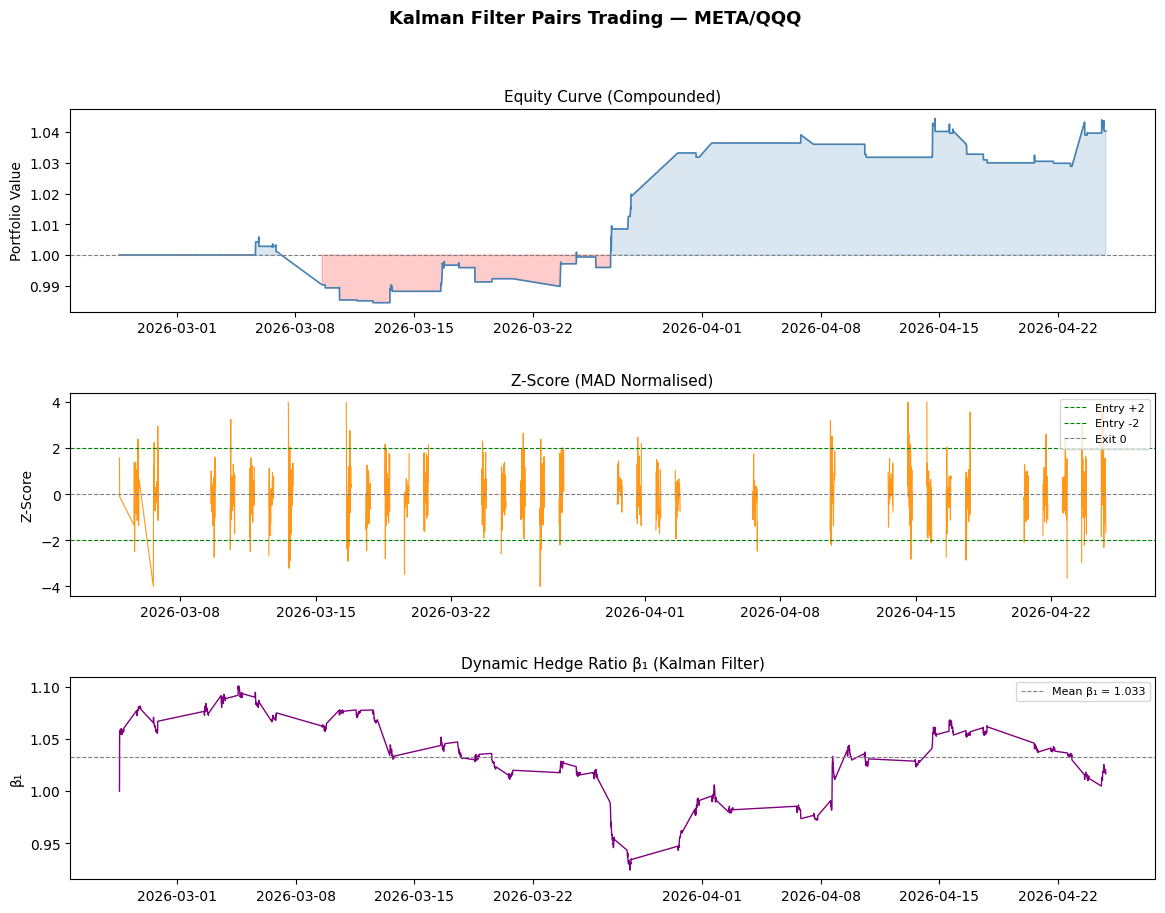

Plot saved.


In [14]:
# =============================================================================
# STEP 6 — VISUALISATION
# =============================================================================

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# --- Panel 1: Equity Curve ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(equity_curve.index, equity_curve.values, color="steelblue", linewidth=1.2)
ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
ax1.set_title("Equity Curve (Compounded)", fontsize=11)
ax1.set_ylabel("Portfolio Value")
ax1.fill_between(equity_curve.index, equity_curve.values, 1,
                 where=equity_curve.values >= 1, alpha=0.2, color="steelblue")
ax1.fill_between(equity_curve.index, equity_curve.values, 1,
                 where=equity_curve.values < 1,  alpha=0.2, color="red")

# --- Panel 2: Z-Score with entry/exit bands ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(zscore_clean.index, zscore_clean.values, color="darkorange",
         linewidth=0.8, alpha=0.9)
ax2.axhline( 2, color="green",  linestyle="--", linewidth=0.8, label="Entry +2")
ax2.axhline(-2, color="green",  linestyle="--", linewidth=0.8, label="Entry -2")
ax2.axhline( 0, color="grey",   linestyle="--", linewidth=0.8, label="Exit 0")
ax2.set_title("Z-Score (MAD Normalised)", fontsize=11)
ax2.set_ylabel("Z-Score")
ax2.legend(fontsize=8, loc="upper right")

# --- Panel 3: Dynamic Hedge Ratio ---
ax3 = fig.add_subplot(gs[2])
ax3.plot(data.index, beta[:, 1], color="purple", linewidth=1.0)
ax3.set_title("Dynamic Hedge Ratio β₁ (Kalman Filter)", fontsize=11)
ax3.set_ylabel("β₁")
ax3.axhline(beta[:, 1].mean(), color="grey", linestyle="--",
            linewidth=0.8, label=f"Mean β₁ = {beta[:,1].mean():.3f}")
ax3.legend(fontsize=8)

plt.suptitle("Kalman Filter Pairs Trading — META/QQQ", fontsize=13, fontweight="bold")
plt.savefig("kalman_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")